# 08 - FESR als gemeinsame Baseline für alle Gase

**FESR** steht für Feature Extraction, Selection and Regression. Diese
Python-Umsetzung folgt der DAV³E-Struktur:

1. zwei Feature-Extraction-Varianten: 120 äquidistante Segmente und ALA,
2. Mittelwert und lineare Steigung je Segment,
3. Standardisierung aus den Trainingsdaten,
4. zwei Feature-Selection-Varianten: Pearson und RFE-LSR,
5. Partial Least Squares Regression (PLSR).

Die Originalanwendung besitzt vier Subsensoren und damit
4 × 120 × 2 = 960 Merkmale. Hier wird verbindlich nur Sensor A,
Kanal 0 verwendet: **1 × 120 × 2 = 240 Merkmale**.

Quelle:
[DAV³E auf GitHub](https://github.com/lmtUds/dav3e-beta) und
[Methodenbeschreibung in JSSS](https://jsss.copernicus.org/articles/12/45/2023/).

## Software, Suchräume und Bedienung der FESR-Baseline

Dieses Notebook läuft standardmäßig über alle Namen in GAS_TARGETS. Zwei
Feature-Extraction- und zwei Feature-Selection-Verfahren ergeben vier
Kandidaten pro Gas.

**Feature Extraction**

- Equidistant: 120 gleich lange Segmente mit je 12 Samples; Mittelwert und
  Steigung ergeben bei einem Kanal 240 Merkmale.
- ALA: 50 anhand des Rekonstruktionsfehlers platzierte Segmente; Grenzen werden
  nur aus dem Trainingsmedian gelernt, Mittelwert und Steigung ergeben 100
  Merkmale.

**Feature Selection und Regression**

- Pearson sortiert nach absoluter Train-Korrelation zum Ziel.
- RFE-LSR aus sklearn.feature_selection.RFE passt wiederholt
  sklearn.linear_model.Ridge an und entfernt das betragsmäßig schwächste
  Merkmal.
- sklearn.cross_decomposition.PLSRegression projiziert korrelierte Merkmale auf
  wenige latente Komponenten und regressiert dort auf die Konzentration.

**Einstellbare Suchräume**

- FEATURE_COUNT_GRID enthält die getesteten Anzahlen ausgewählter Merkmale.
- PLS_COMPONENT_GRID enthält die getesteten PLS-Dimensionen. Die Komponentenzahl
  darf die Merkmalszahl nicht überschreiten.
- Ridge-alpha für RFE-LSR steht in fesr_baseline.py und ist standardmäßig 1.
- Die ALA-Segmentzahl ist im Extraktionsblock auf 50 gesetzt.

Validation wählt FE, FS, Merkmalszahl und PLS-Komponenten. Die Tabellen zeigen
auch Testwerte aller Kandidaten, diese beeinflussen die Auswahl aber nicht.
csv und json aus der Python-Standardbibliothek schreiben die Baseline-Artefakte;
NumPy, scikit-learn und Matplotlib übernehmen Berechnung und Darstellung.

In [1]:
# Gemeinsame Suchräume für alle zehn Zielgase
FEATURE_COUNT_GRID = (2, 4, 8, 12, 16, 24, 32, 48, 64, 96, 120, 180, 240)
PLS_COMPONENT_GRID = (1, 2, 3, 4, 6, 8, 12, 16, 20)

In [2]:
from pathlib import Path
from html import escape
import csv
import json
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Neuaufbau"
sys.path.insert(0, str(HERE.resolve()))

from dataset_pipeline import *
from fesr_baseline import (
    extract_fesr_features,
    fit_fesr,
    regression_metrics,
)
from physics_features import (
    extract_ala_features,
    learn_ala_breakpoints,
)

plt.style.use("seaborn-v0_8-whitegrid")
splits = prepare_splits("stored")

def show_table(rows, columns, digits=3):
    def formatted(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.{digits}f}"
        return str(value)
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join(
        "<tr>" + "".join(
            f"<td>{escape(formatted(row[column]))}</td>" for column in columns
        ) + "</tr>" for row in rows
    )
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

## 1. Einmalige Merkmalsextraktion

In [3]:
equidistant_features = {}
ala_features = {}
train_reference = np.median(splits["train"]["X"][:, 0, :], axis=0)
ala_breakpoints = learn_ala_breakpoints(
    train_reference, n_segments=50
)
for split in SPLIT_NAMES:
    values, equidistant_names = extract_fesr_features(splits[split]["X"])
    equidistant_features[split] = values
    values, ala_names = extract_ala_features(
        splits[split]["X"], ala_breakpoints
    )
    ala_features[split] = values

extraction_variants = {
    "Equidistant": (equidistant_features, equidistant_names),
    "ALA": (ala_features, ala_names),
}

print("Sensorachse der Rohdaten:", splits["train"]["X"].shape[1])
print("Äquidistant: 120 Segmente, 240 Merkmale")
print("ALA: 50 Segmente, 100 Merkmale")
print("Merkmale pro Segment: Mittelwert und Steigung")
print("ALA-Grenzen ausschließlich aus Trainingsmedian gelernt")
print("Trainingszeilen:", equidistant_features["train"].shape[0])

Sensorachse der Rohdaten: 1
Äquidistant: 120 Segmente, 240 Merkmale
ALA: 50 Segmente, 100 Merkmale
Merkmale pro Segment: Mittelwert und Steigung
ALA-Grenzen ausschließlich aus Trainingsmedian gelernt
Trainingszeilen: 1090


## 2. Auswahl und Regression für alle Gase

Pearson- und RFE-LSR-Rangfolgen werden für jedes Gas ausschließlich aus
Train erzeugt. Validation wählt die FE-FS-Kombination, die Anzahl der
Rangmerkmale und die PLS-Komponenten anhand des RMSE. Weder Test noch
test_extra beeinflussen Auswahl oder Training.

In [4]:
results = {}
metric_rows = []
hyperparameter_rows = []
candidate_rows = []
selected_feature_rows = []

start_time = time.perf_counter()
for gas in GAS_TARGETS:
    gas_targets = {
        split: splits[split]["targets"][gas].astype(float)
        for split in SPLIT_NAMES
    }
    gas_start = time.perf_counter()
    candidates = []
    for extraction_name, (gas_features, gas_feature_names) in extraction_variants.items():
        for selection_name in ("pearson", "rfe_lsr"):
            candidate = fit_fesr(
                gas_features,
                gas_targets,
                gas_feature_names,
                feature_counts=FEATURE_COUNT_GRID,
                component_counts=PLS_COMPONENT_GRID,
                selection_method=selection_name,
            )
            candidates.append((candidate.validation_rmse, extraction_name,
                               selection_name, candidate))
            candidate_test = regression_metrics(
                gas_targets["test"], candidate.predictions["test"]
            )
            candidate_extra = regression_metrics(
                gas_targets["test_extra"],
                candidate.predictions["test_extra"],
            )
            candidate_rows.append({
                "Gas": gas,
                "Feature Extraction": extraction_name,
                "Feature Selection": selection_name,
                "Merkmale": candidate.n_features,
                "PLS-Komponenten": candidate.n_components,
                "Val-RMSE": candidate.validation_rmse,
                "Test-R2": candidate_test["R2"],
                "Test-RMSE": candidate_test["RMSE"],
                "Extra-R2": candidate_extra["R2"],
                "Extra-RMSE": candidate_extra["RMSE"],
            })

    _, extraction_name, selection_name, result = min(
        candidates, key=lambda item: (item[0], item[1], item[2])
    )
    results[gas] = result
    hyperparameter_rows.append({
        "Gas": gas,
        "Feature Extraction": extraction_name,
        "Feature Selection": selection_name,
        "Merkmale": result.n_features,
        "PLS-Komponenten": result.n_components,
        "Val-RMSE": result.validation_rmse,
    })
    for split in SPLIT_NAMES:
        metric_rows.append({
            "Gas": gas,
            "Split": split,
            **regression_metrics(
                gas_targets[split], result.predictions[split]
            ),
        })
    for rank, (index, name) in enumerate(
        zip(result.selected_indices, result.selected_names), start=1
    ):
        selected_feature_rows.append({
            "Gas": gas,
            "Feature Extraction": extraction_name,
            "Feature Selection": selection_name,
            "Rang": rank,
            "Merkmalsindex": int(index),
            "Merkmal": name,
        })
    print(
        f"{gas:18s}: {extraction_name:11s} + {selection_name:8s}, "
        f"{result.n_features:3d} Merkmale, "
        f"{result.n_components:2d} PLS-Komponenten, "
        f"{time.perf_counter() - gas_start:5.1f} s"
    )

print(f"Gesamtlaufzeit: {time.perf_counter() - start_time:.1f} s")

acetic_acid       : Equidistant + rfe_lsr ,   8 Merkmale,  3 PLS-Komponenten,   2.2 s
acetone           : Equidistant + rfe_lsr ,  96 Merkmale, 16 PLS-Komponenten,   2.2 s
carbon_monoxide   : Equidistant + rfe_lsr , 120 Merkmale, 20 PLS-Komponenten,   2.3 s
ethanol           : ALA         + rfe_lsr ,  32 Merkmale,  4 PLS-Komponenten,   2.2 s
ethyl_acetate     : ALA         + rfe_lsr ,  48 Merkmale, 16 PLS-Komponenten,   2.2 s
formaldehyde      : ALA         + pearson ,  96 Merkmale,  4 PLS-Komponenten,   2.2 s
hydrogen          : Equidistant + rfe_lsr ,  64 Merkmale,  8 PLS-Komponenten,   2.2 s
isopropanol       : Equidistant + pearson ,  96 Merkmale,  2 PLS-Komponenten,   2.2 s
toluene           : ALA         + rfe_lsr ,  24 Merkmale,  6 PLS-Komponenten,   2.2 s
xylene            : Equidistant + rfe_lsr ,  48 Merkmale,  8 PLS-Komponenten,   2.3 s
Gesamtlaufzeit: 22.0 s


## 3. Gemeinsame Baseline-Tabelle

In [5]:
show_table(
    hyperparameter_rows,
    ["Gas", "Feature Extraction", "Feature Selection",
     "Merkmale", "PLS-Komponenten", "Val-RMSE"],
)
show_table(
    candidate_rows,
    ["Gas", "Feature Extraction", "Feature Selection",
     "Merkmale", "PLS-Komponenten", "Val-RMSE",
     "Test-R2", "Test-RMSE", "Extra-R2", "Extra-RMSE"],
)

compact_rows = []
for gas in GAS_TARGETS:
    by_split = {
        row["Split"]: row
        for row in metric_rows if row["Gas"] == gas
    }
    compact_rows.append({
        "Gas": gas,
        "FE": next(row["Feature Extraction"] for row in hyperparameter_rows
                   if row["Gas"] == gas),
        "FS": next(row["Feature Selection"] for row in hyperparameter_rows
                   if row["Gas"] == gas),
        "R2 train": by_split["train"]["R2"],
        "R2 val": by_split["val"]["R2"],
        "R2 test": by_split["test"]["R2"],
        "R2 test_extra": by_split["test_extra"]["R2"],
        "RMSE test": by_split["test"]["RMSE"],
        "RMSE test_extra": by_split["test_extra"]["RMSE"],
    })
show_table(compact_rows, list(compact_rows[0]))

Gas,Feature Extraction,Feature Selection,Merkmale,PLS-Komponenten,Val-RMSE
acetic_acid,Equidistant,rfe_lsr,8,3,35.852
acetone,Equidistant,rfe_lsr,96,16,17.284
carbon_monoxide,Equidistant,rfe_lsr,120,20,191.706
ethanol,ALA,rfe_lsr,32,4,31.836
ethyl_acetate,ALA,rfe_lsr,48,16,15.280
formaldehyde,ALA,pearson,96,4,36.084
hydrogen,Equidistant,rfe_lsr,64,8,118.096
isopropanol,Equidistant,pearson,96,2,29.519
toluene,ALA,rfe_lsr,24,6,21.428
xylene,Equidistant,rfe_lsr,48,8,20.975


Gas,Feature Extraction,Feature Selection,Merkmale,PLS-Komponenten,Val-RMSE,Test-R2,Test-RMSE,Extra-R2,Extra-RMSE
acetic_acid,Equidistant,pearson,96,6,35.900,0.459,29.019,-0.014,144.570
acetic_acid,Equidistant,rfe_lsr,8,3,35.852,0.470,28.738,0.057,139.455
acetic_acid,ALA,pearson,48,16,36.643,0.440,29.538,-0.261,161.209
acetic_acid,ALA,rfe_lsr,12,6,35.885,0.423,29.980,-0.040,146.431
acetone,Equidistant,pearson,120,12,17.733,0.774,17.873,-0.943,200.658
acetone,Equidistant,rfe_lsr,96,16,17.284,0.780,17.656,-0.936,200.246
acetone,ALA,pearson,48,20,18.937,0.719,19.921,-1.186,212.826
acetone,ALA,rfe_lsr,64,20,17.815,0.753,18.687,-1.357,220.962
carbon_monoxide,Equidistant,pearson,240,20,204.300,0.851,205.839,-0.428,653.293
carbon_monoxide,Equidistant,rfe_lsr,120,20,191.706,0.865,196.276,-0.404,647.931


Gas,FE,FS,R2 train,R2 val,R2 test,R2 test_extra,RMSE test,RMSE test_extra
acetic_acid,Equidistant,rfe_lsr,0.422,0.321,0.470,0.057,28.738,139.455
acetone,Equidistant,rfe_lsr,0.863,0.802,0.780,-0.936,17.656,200.246
carbon_monoxide,Equidistant,rfe_lsr,0.912,0.882,0.865,-0.404,196.276,647.931
ethanol,ALA,rfe_lsr,0.285,0.388,0.365,-0.739,34.456,189.370
ethyl_acetate,ALA,rfe_lsr,0.883,0.871,0.876,0.509,14.170,101.389
formaldehyde,ALA,pearson,0.234,0.262,0.373,-0.159,32.576,92.825
hydrogen,Equidistant,rfe_lsr,0.919,0.933,0.903,0.363,144.496,368.132
isopropanol,Equidistant,pearson,0.241,0.405,0.255,-0.945,35.364,200.132
toluene,ALA,rfe_lsr,0.143,0.011,0.130,-1.524,20.584,113.317
xylene,Equidistant,rfe_lsr,0.753,0.774,0.729,-0.459,23.955,174.483


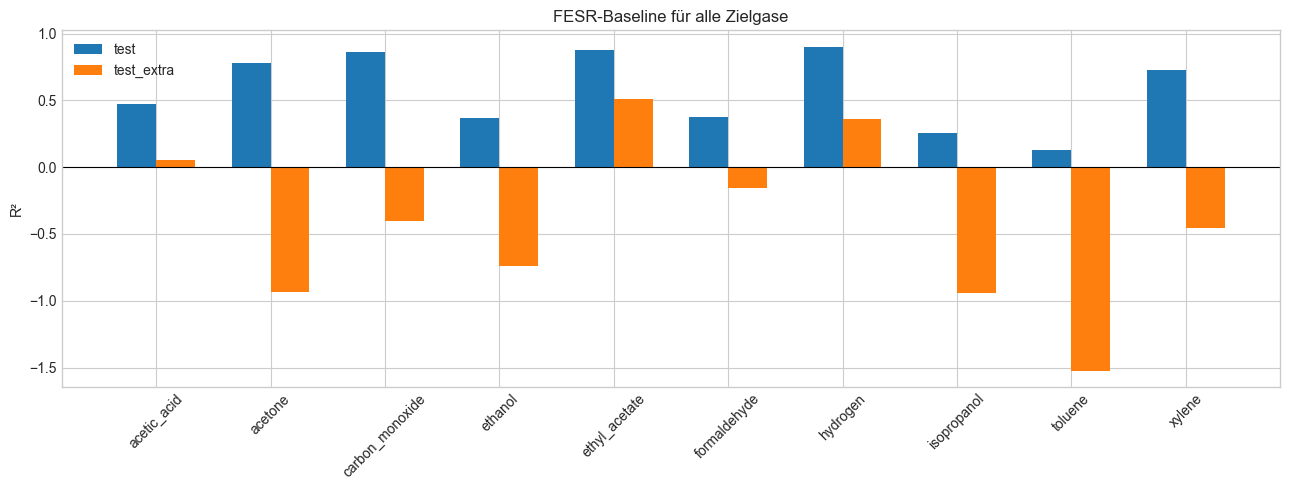

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(GAS_TARGETS))
width = 0.34
regular = [
    next(row["R2"] for row in metric_rows
         if row["Gas"] == gas and row["Split"] == "test")
    for gas in GAS_TARGETS
]
extra = [
    next(row["R2"] for row in metric_rows
         if row["Gas"] == gas and row["Split"] == "test_extra")
    for gas in GAS_TARGETS
]
ax.bar(x - width / 2, regular, width, label="test")
ax.bar(x + width / 2, extra, width, label="test_extra")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    xticks=x,
    xticklabels=GAS_TARGETS,
    ylabel="R²",
    title="FESR-Baseline für alle Zielgase",
)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Vorhersage-Scatterplots des regulären Tests

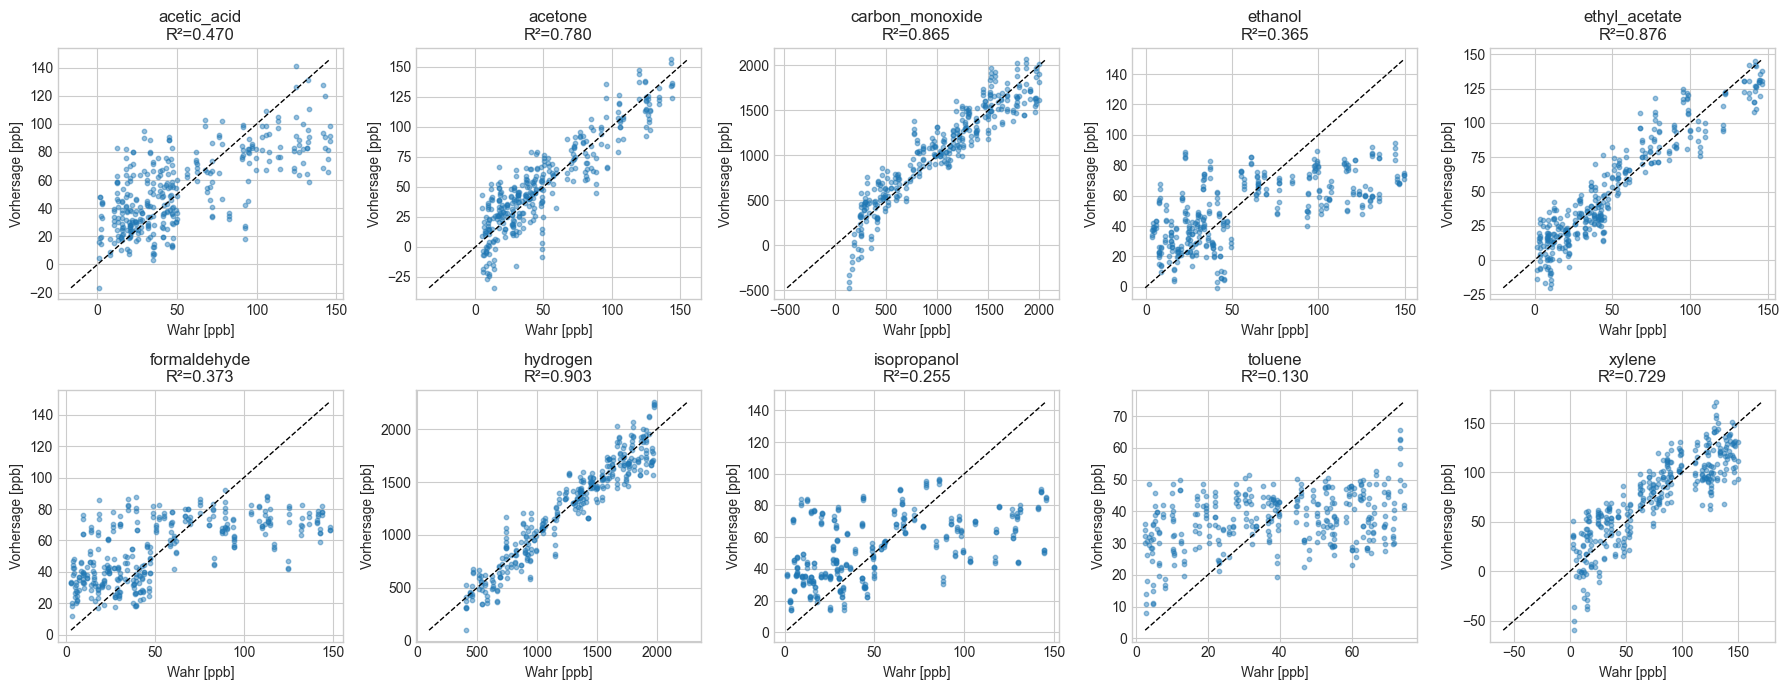

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, gas in zip(axes.flat, GAS_TARGETS):
    truth = splits["test"]["targets"][gas].astype(float)
    prediction = results[gas].predictions["test"]
    score = regression_metrics(truth, prediction)
    lower = min(float(truth.min()), float(prediction.min()))
    upper = max(float(truth.max()), float(prediction.max()))
    ax.scatter(truth, prediction, s=10, alpha=0.45)
    ax.plot([lower, upper], [lower, upper], "k--", linewidth=1)
    ax.set(
        xlabel="Wahr [ppb]",
        ylabel="Vorhersage [ppb]",
        title=f"{gas}\nR²={score['R2']:.3f}",
    )
plt.tight_layout()
plt.show()

## 5. Reproduzierbare Baseline-Dateien exportieren

In [8]:
output_dir = project_root() / "Data" / "seminar_baselines"
output_dir.mkdir(parents=True, exist_ok=True)

metrics_path = output_dir / "fesr_all_gases_metrics.csv"
with metrics_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(
        handle, fieldnames=["Gas", "Split", "R2", "MSE", "RMSE", "MAE"]
    )
    writer.writeheader()
    writer.writerows(metric_rows)

candidates_path = output_dir / "fesr_candidate_combinations.csv"
with candidates_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=[
            "Gas", "Feature Extraction", "Feature Selection",
            "Merkmale", "PLS-Komponenten", "Val-RMSE",
            "Test-R2", "Test-RMSE", "Extra-R2", "Extra-RMSE",
        ],
    )
    writer.writeheader()
    writer.writerows(candidate_rows)

selection_path = output_dir / "fesr_selected_features.csv"
with selection_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=[
            "Gas", "Feature Extraction", "Feature Selection",
            "Rang", "Merkmalsindex", "Merkmal",
        ],
    )
    writer.writeheader()
    writer.writerows(selected_feature_rows)

config_path = output_dir / "fesr_config.json"
config = {
    "name": "FESR single-channel seminar baseline",
    "source_implementation": "https://github.com/lmtUds/dav3e-beta",
    "dataset_doi": ZENODO_DOI,
    "physical_sensor": PHYSICAL_SENSOR,
    "sub_sensor_index": SUB_SENSOR_INDEX,
    "sensor_dimension": SENSOR_DIMENSION,
    "feature_extraction_variants": {
        "Equidistant": {
            "n_segments": 120,
            "n_extracted_features": 240,
        },
        "ALA": {
            "n_segments": 50,
            "n_extracted_features": 100,
            "breakpoints_learned_from": "train median only",
        },
    },
    "features_per_segment": ["mean", "linear_slope_per_s"],
    "feature_selection_variants": [
        "Pearson absolute correlation, train only",
        "RFE-LSR with Ridge(alpha=1), train only",
    ],
    "regression": "PLSRegression",
    "feature_count_grid": list(FEATURE_COUNT_GRID),
    "pls_component_grid": list(PLS_COMPONENT_GRID),
    "hyperparameter_split": "val",
    "evaluation_splits": list(SPLIT_NAMES),
    "per_gas": {
        row["Gas"]: {
            "feature_extraction": row["Feature Extraction"],
            "feature_selection": row["Feature Selection"],
            "n_features": row["Merkmale"],
            "n_components": row["PLS-Komponenten"],
            "validation_rmse": row["Val-RMSE"],
        }
        for row in hyperparameter_rows
    },
}
config_path.write_text(
    json.dumps(config, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print(metrics_path)
print(candidates_path)
print(selection_path)
print(config_path)

\\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_baselines\fesr_all_gases_metrics.csv
\\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_baselines\fesr_candidate_combinations.csv
\\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_baselines\fesr_selected_features.csv
\\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_baselines\fesr_config.json


## Baseline-Regel ab Notebook 08

Ab hier bezeichnet **FESR-Baseline** genau diese Konfiguration:

- Sensor A, Subsensor 0, Sensorachse 1;
- alle Konzentrationen;
- UGM-gruppierte Splits aus Notebook 01;
- test_extra als exklusiver letzter Abschnitt;
- äquidistante Segmentierung und ALA als FE-Kandidaten;
- Pearson und RFE-LSR als FS-Kandidaten, jeweils nur auf Train;
- Auswahl von FE, FS, Merkmalszahl und PLS-Komponenten nur auf Validation;
- Test und test_extra ausschließlich zur Endbewertung.

Das ist eine methodentreue Python-Adaption und keine bytegenaue
MATLAB-Ausführung von DAV³E. Insbesondere ersetzen scikit-learn Ridge,
RFE und PLSRegression die entsprechenden MATLAB-Komponenten.